In [2]:
import pandas as pd
import numpy as np


Step 2

In [ ]:
# 2.1
df = pd.read_excel('credit_dataset.xls', header=1)
print(df.shape[0])

30000


In [ ]:
# 2.2
print(df.shape[1]-1)

# answer is 24 excluding outcome

24


2.3

Sex - Equal Credit Opportunity Act (ECOA) / Regulation B; also Title VII framing for sex discrimination
Age - ECOA (age is a prohibited basis in credit); ADEA is the usual employment-age statute if you want a parallel
Marriage ( Marital status) - ECOA (marital status is an explicit prohibited basis; FAQ allows it here)



Step 3

3.1 

Dataset outcome = Y

In [14]:
# 3.2 Creditworthiness formula
# Start at 100; deduct 10 points per month of delay across PAY_0, PAY_2..PAY_6.
# Only positive PAY values count as delay (-2, -1, 0 do not). Clip at 0.
# score = max(0, 100 - 10 * sum(max(PAY_i, 0)))

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
delay_months = df[pay_cols].clip(lower=0).sum(axis=1)
df['creditworthiness'] = (100 - 10 * delay_months).clip(lower=0)

# sanity check: ID 1 should be 60 (delays 2+2=4 → 100-40)
print(df.loc[df['ID'] == 1, ['ID'] + pay_cols + ['creditworthiness']])
print(df['creditworthiness'].describe())

   ID  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  creditworthiness
0   1      2      2     -1     -1     -2     -2                60
count    30000.000000
mean        85.055667
std         28.064981
min          0.000000
25%         80.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: creditworthiness, dtype: float64


3.3

protected class attribute = age

3.4 

Unprivileged: older (age ≥ 40)
Privileged: younger (age < 40)

In [15]:
# 3.5
train_df = df.sample(frac=0.5, random_state=42)
# drop the target for test data
test_df = df.drop(train_df.index)

# Report privileged/unprivileged counts in train and test.
for name, split in [('train', train_df), ('test', test_df)]:
    priv = (split['AGE'] < 40).sum()
    unpriv = (split['AGE'] >= 40).sum()
    print(f'{name}: privileged (young)={priv}, unprivileged (old)={unpriv}, n={len(split)}')

train: privileged (young)=10467, unprivileged (old)=4533, n=15000
test: privileged (young)=10389, unprivileged (old)=4611, n=15000


Step 4

* This is where i implement the 65 threshold.

<Axes: >

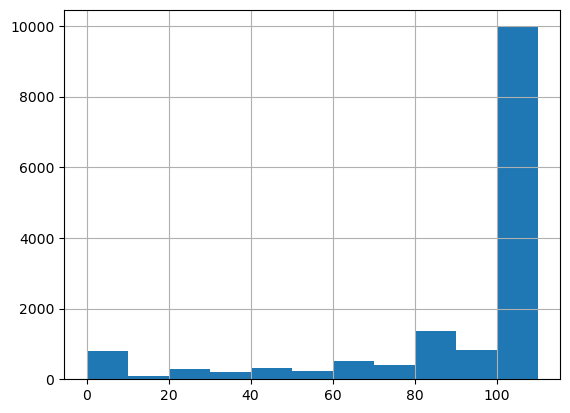

In [ ]:
# 4.1
#  There is 15000 customers in the training data
train_df['creditworthiness'].hist(bins=range(0, 111, 10))

In [18]:
# 4.2

y = train_df['default payment next month']  # 0=approved(good), 1=denied(bad)
score = train_df['creditworthiness']

def profit_for_threshold(x):
    approve = score >= x
    true_approve = (y == 0)
    p = np.where(true_approve & approve, 10,
        np.where(true_approve & ~approve, -5,
        np.where(~true_approve & approve, -10, 0)))
    return p.sum()

thresholds = range(10, 101, 5) #from score 10 too 100 with increament of 5
profits = {x: profit_for_threshold(x) for x in thresholds}
best_x = max(profits, key=profits.get)
print(profits)
print('best threshold', best_x, 'max profit', profits[best_x])

{10: 86190, 15: 86020, 20: 86020, 25: 86335, 30: 86335, 35: 85600, 40: 85600, 45: 85530, 50: 85530, 55: 84425, 60: 84425, 65: 82095, 70: 82095, 75: 79205, 80: 79205, 85: 69485, 90: 69485, 95: 62385, 100: 62385}
best threshold 25 max profit 86335


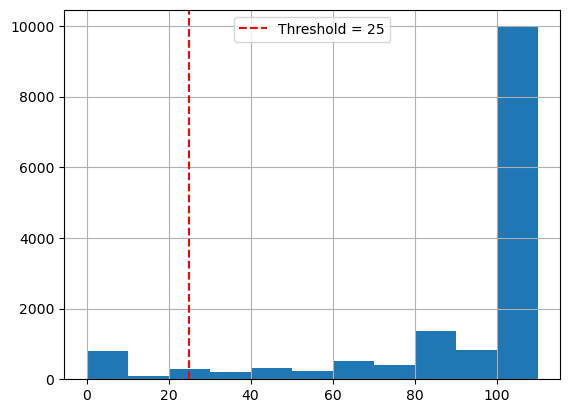

In [20]:
# 4.3

ax = train_df['creditworthiness'].hist(bins=range(0, 111, 10))
ax.axvline(25, color='red', linestyle='--', label='Threshold = 25')
ax.legend()

In [22]:
# 4.4

threshold = 25
train = train_df.copy()
train['outcome'] = np.where(
    train['creditworthiness'] >= threshold, 'Favorable (Approved)', 'Unfavorable (Declined)'
)
train['group'] = np.where(train['AGE'] < 40, 'Privileged (Young)', 'Unprivileged (Old)')
table = pd.crosstab(train['outcome'], train['group'])
# put Unfavorable row first to match FAQ table layout
table = table.reindex(['Unfavorable (Declined)', 'Favorable (Approved)'])
print(table)

group                   Privileged (Young)  Unprivileged (Old)
outcome                                                       
Unfavorable (Declined)                 815                 366
Favorable (Approved)                  9652                4167


Analysis, not much age bias noticed. That’s expected with threshold 25: almost everyone is approved. Disparate Impact would be about (0.919/0.922 ≈ 1.0) (near ideal)

Old has fewer approvals mainly because there are fewer older people in the train set — not because the threshold treats them differently.